# Fine-tune BERT for email triage

This notebook fine-tunes `bert-base-uncased` to classify an email into one of five workflow categories. It reads only the email subject and body (`bert_text`); attachment parsing belongs to the downstream document-verification stage.

The supplied `test.csv` remains untouched until the model and training settings have been selected using a validation split from `train.csv`.

## Workflow

1. Configure paths and training settings.
2. Load and validate the labelled data.
3. Split and tokenize the training data.
4. Fine-tune BERT and select the best validation checkpoint.
5. Evaluate once on the held-out test set.
6. Save the model and classify the original email JSON files.

## 1. Environment setup

Run the next cell once in a fresh notebook environment, then restart the kernel if requested. Skip it when these packages are already installed.

In [1]:
%pip install -q "transformers[torch]" datasets scikit-learn pandas matplotlib

In [2]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import torch
from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"PyTorch device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

PyTorch device: GPU


## 2. Configuration

Local Jupyter discovers the repository paths automatically. In Colab, run the mount cell and then the path-discovery cell. It searches all mounted Drive locations, including `MyDrive` and shared drives, for a folder containing both `train.csv` and `test.csv`.

In [3]:
from google.colab import drive
drive.mount('/content/drive') 

Mounted at /content/drive


In [4]:
from pathlib import Path

DRIVE_ROOT = Path("/content/drive")
DATASET_INDEX = 0

drive_data_dirs = sorted({
    train_path.parent.resolve()
    for train_path in DRIVE_ROOT.rglob("train.csv")
    if (train_path.parent / "test.csv").is_file()
}, key=str)

print("Matching dataset folders:")
for index, folder in enumerate(drive_data_dirs):
    print(f"[{index}] {folder}")

DATA_DIR_OVERRIDE = drive_data_dirs[DATASET_INDEX]

print(f"\nSelected exact path: {DATA_DIR_OVERRIDE}")
print(
    f"Copyable setting: "
    f"DATA_DIR_OVERRIDE = Path({str(DATA_DIR_OVERRIDE)!r})"
)

Matching dataset folders:
[0] /content/drive/MyDrive/Grabbers---Averis-Hackathon/backend/data_prep/data_prep/cleaned_data

Selected exact path: /content/drive/MyDrive/Grabbers---Averis-Hackathon/backend/data_prep/data_prep/cleaned_data
Copyable setting: DATA_DIR_OVERRIDE = Path('/content/drive/MyDrive/Grabbers---Averis-Hackathon/backend/data_prep/data_prep/cleaned_data')


In [5]:
# Discover the exact Google Drive folder containing both dataset files.
DRIVE_ROOT = Path('/content/drive')
DATASET_INDEX = 0  # Change this only when multiple matching folders are listed.

if not DRIVE_ROOT.is_dir():
    raise FileNotFoundError('Google Drive is not mounted at /content/drive. Run the mount cell first.')

drive_data_dirs = sorted({
    train_path.parent.resolve()
    for train_path in DRIVE_ROOT.rglob('train.csv')
    if (train_path.parent / 'test.csv').is_file()
}, key=str)

if not drive_data_dirs:
    visible_roots = [str(path) for path in DRIVE_ROOT.iterdir()]
    raise FileNotFoundError(
        'Drive is mounted, but no folder contains both train.csv and test.csv. '
        f'Visible Drive roots: {visible_roots}. Upload or unzip the dataset first.'
    )

print('Matching dataset folders:')
for index, folder in enumerate(drive_data_dirs):
    print(f'[{index}] {folder}')

if not 0 <= DATASET_INDEX < len(drive_data_dirs):
    raise IndexError(f'DATASET_INDEX must be between 0 and {len(drive_data_dirs) - 1}')

DATA_DIR_OVERRIDE = drive_data_dirs[DATASET_INDEX]
print(f'\nSelected exact path: {DATA_DIR_OVERRIDE}')
print(f'Copyable setting: DATA_DIR_OVERRIDE = Path({str(DATA_DIR_OVERRIDE)!r})')

Matching dataset folders:
[0] /content/drive/MyDrive/Grabbers---Averis-Hackathon/backend/data_prep/data_prep/cleaned_data

Selected exact path: /content/drive/MyDrive/Grabbers---Averis-Hackathon/backend/data_prep/data_prep/cleaned_data
Copyable setting: DATA_DIR_OVERRIDE = Path('/content/drive/MyDrive/Grabbers---Averis-Hackathon/backend/data_prep/data_prep/cleaned_data')


In [6]:
# In Colab, DATA_DIR_OVERRIDE is set by the path-discovery cell above.
# For a manual override, use: DATA_DIR_OVERRIDE = Path('/content/drive/.../cleaned_data')
DATA_DIR_OVERRIDE = globals().get('DATA_DIR_OVERRIDE')
MODEL_NAME = 'bert-base-uncased'
MAX_LENGTH = 512
VALIDATION_SIZE = 0.20

def find_data_dir(override=None):
    candidates = [
        Path(override).expanduser() if override else None,
        Path.cwd() / 'backend' / 'data_prep' / 'cleaned_data',
        Path.cwd() / 'data_prep' / 'cleaned_data',
        Path.cwd().parent / 'data_prep' / 'cleaned_data',
    ]
    for candidate in candidates:
        if candidate and all((candidate / name).is_file() for name in ('train.csv', 'test.csv')):
            return candidate.resolve()
    raise FileNotFoundError(
        'Could not find train.csv and test.csv. Set DATA_DIR_OVERRIDE to the cleaned_data folder.'
    )

DATA_DIR = find_data_dir(DATA_DIR_OVERRIDE)
ARTIFACT_DIR = DATA_DIR.parents[1] / 'model' if DATA_DIR.parent.name == 'data_prep' else Path.cwd() / 'bert_artifacts'
MODEL_DIR = ARTIFACT_DIR / 'email_multiclass_classifier'
RESULTS_DIR = ARTIFACT_DIR / 'results'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Data:      {DATA_DIR}')
print(f'Artifacts: {ARTIFACT_DIR.resolve()}')

Data:      /content/drive/MyDrive/Grabbers---Averis-Hackathon/backend/data_prep/data_prep/cleaned_data
Artifacts: /content/drive/MyDrive/Grabbers---Averis-Hackathon/backend/data_prep/model


## 3. Load and validate the dataset

The label order matches `backend/data_prep/build_dataset.py` and must remain stable so saved model IDs keep the same meaning. Each input file must contain non-empty `bert_text` and a known `category`.

In [7]:
LABELS = ['BL_COMPARISON', 'SI_REQUEST', 'INVOICE_QUERY', 'GENERAL', 'SPAM']
label2id = {label: index for index, label in enumerate(LABELS)}
id2label = {index: label for label, index in label2id.items()}

def load_csv(path):
    frame = pd.read_csv(path)
    missing = {'bert_text', 'category'} - set(frame.columns)
    if missing:
        raise ValueError(f'{path.name} is missing columns: {sorted(missing)}')
    empty_text = frame['bert_text'].isna() | frame['bert_text'].astype(str).str.strip().eq('')
    if empty_text.any():
        raise ValueError(f'{path.name} has {int(empty_text.sum())} rows with empty bert_text')
    unknown = sorted(set(frame['category'].dropna()) - set(LABELS))
    if frame['category'].isna().any() or unknown:
        raise ValueError(f'{path.name} has missing or unknown categories: {unknown}')
    return frame

def to_dataset(frame):
    model_frame = pd.DataFrame({
        'text': frame['bert_text'].astype(str),
        'labels': frame['category'].map(label2id).astype(int),
    })
    return Dataset.from_pandas(model_frame, preserve_index=False)

train_frame = load_csv(DATA_DIR / 'train.csv')
test_frame = load_csv(DATA_DIR / 'test.csv')
distribution = pd.concat(
    [train_frame['category'].value_counts().rename('train'), test_frame['category'].value_counts().rename('test')],
    axis=1,
).reindex(LABELS).fillna(0).astype(int)
display(distribution)

,train,test
category,,
BL_COMPARISON,125,4
SI_REQUEST,212,4
INVOICE_QUERY,71,4
GENERAL,56,4
SPAM,36,4


### 3.1 Inspect the CSVs (read-only diagnostics)

These checks describe dataset size, quality, balance, and train/test similarity. They do not modify either dataframe or any model-training input.

In [8]:
import matplotlib.pyplot as plt

csv_summary = pd.DataFrame({
    'rows': [len(train_frame), len(test_frame)],
    'columns': [train_frame.shape[1], test_frame.shape[1]],
    'duplicate_email_ids': [train_frame['email_id'].duplicated().sum(), test_frame['email_id'].duplicated().sum()],
    'duplicate_text_rows': [train_frame['bert_text'].duplicated().sum(), test_frame['bert_text'].duplicated().sum()],
    'empty_model_text': [train_frame['bert_text'].isna().sum(), test_frame['bert_text'].isna().sum()],
}, index=['train.csv', 'test.csv'])
display(csv_summary)

model_columns = ['email_id', 'category', 'rule', 'subject', 'bert_text']
schema_summary = pd.DataFrame({
    'dtype': train_frame[model_columns].dtypes.astype(str),
    'train_missing': train_frame[model_columns].isna().sum(),
    'test_missing': test_frame[model_columns].isna().sum(),
})
display(schema_summary)

# Compare normalized full texts without changing the original bert_text values.
train_normalized_text = train_frame['bert_text'].str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()
test_normalized_text = test_frame['bert_text'].str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()
exact_overlap_mask = test_normalized_text.isin(set(train_normalized_text))
train_rules = set(train_frame['rule'].dropna()) if 'rule' in train_frame else set()
test_rules = set(test_frame['rule'].dropna()) if 'rule' in test_frame else set()

print(f'Normalized test texts also present in train: {int(exact_overlap_mask.sum())}/{len(test_frame)}')
print(f'Test rule families also present in train: {len(test_rules & train_rules)}/{len(test_rules)}')
if exact_overlap_mask.any():
    display(test_frame.loc[exact_overlap_mask, ['email_id', 'category', 'rule', 'subject']])

,rows,columns,duplicate_email_ids,duplicate_text_rows,empty_model_text
train.csv,500,33,0,13,0
test.csv,20,33,0,0,0


,dtype,train_missing,test_missing
email_id,object,0,0
category,object,0,0
rule,object,0,0
subject,object,0,0
bert_text,object,0,0


Normalized test texts also present in train: 2/20
Test rule families also present in train: 15/15


,email_id,category,rule,subject
5,email_072,SPAM,spam_prize,Increase your shipping revenue with this ONE w...
11,email_294,GENERAL,gen_outstanding,daily Berthing Report - 14 JAN 2026


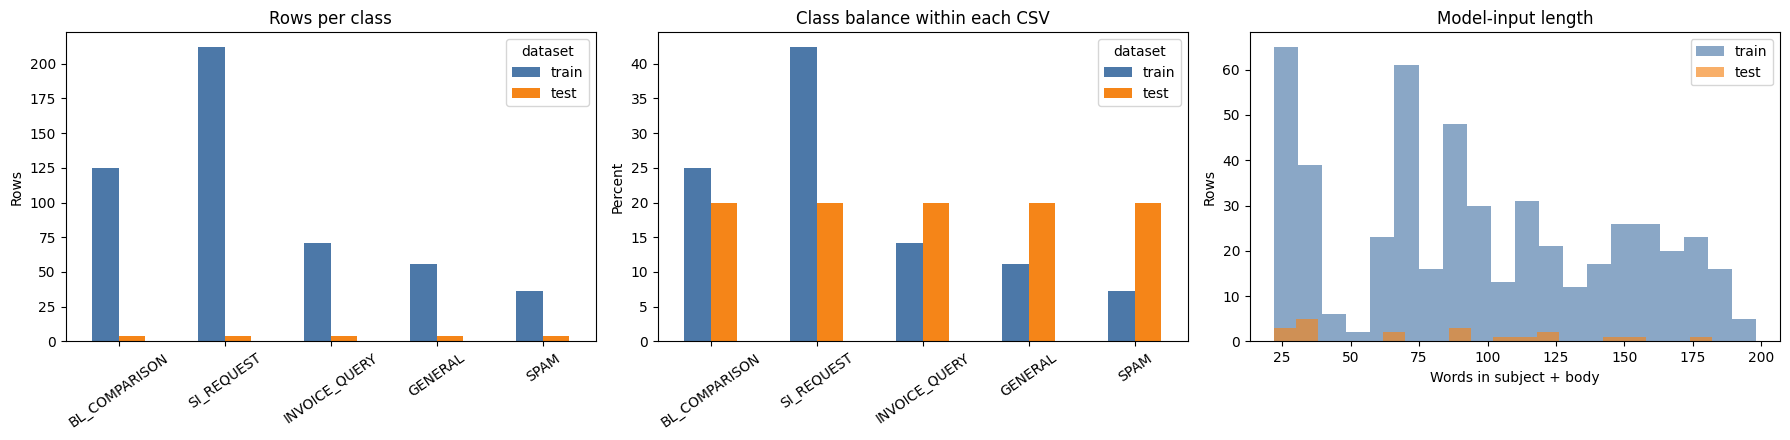

In [9]:
diagnostic_frame = pd.concat([
    train_frame.assign(dataset='train'),
    test_frame.assign(dataset='test'),
] , ignore_index=True)
diagnostic_frame = diagnostic_frame.assign(
    word_count=diagnostic_frame['bert_text'].str.split().str.len()
)

class_counts = pd.crosstab(diagnostic_frame['category'], diagnostic_frame['dataset']).reindex(index=LABELS, columns=['train', 'test'], fill_value=0)
class_percent = class_counts.div(class_counts.sum(axis=0), axis=1).mul(100)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
class_counts.plot(kind='bar', ax=axes[0], color=['#4C78A8', '#F58518'])
axes[0].set(title='Rows per class', xlabel='', ylabel='Rows')
axes[0].tick_params(axis='x', rotation=35)

class_percent.plot(kind='bar', ax=axes[1], color=['#4C78A8', '#F58518'])
axes[1].set(title='Class balance within each CSV', xlabel='', ylabel='Percent')
axes[1].tick_params(axis='x', rotation=35)

for dataset_name, color in [('train', '#4C78A8'), ('test', '#F58518')]:
    values = diagnostic_frame.loc[diagnostic_frame['dataset'].eq(dataset_name), 'word_count']
    axes[2].hist(values, bins=20, alpha=0.65, label=dataset_name, color=color)
axes[2].set(title='Model-input length', xlabel='Words in subject + body', ylabel='Rows')
axes[2].legend()

fig.tight_layout()
plt.show()

## 4. Create training and validation datasets

A stratified split preserves class proportions. The supplied test set is converted separately and is not passed to the trainer during model selection.

In [10]:
fit_frame, validation_frame = train_test_split(
    train_frame,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    stratify=train_frame['category'],
)

dataset = DatasetDict({
    'train': to_dataset(fit_frame),
    'validation': to_dataset(validation_frame),
})
test_dataset = to_dataset(test_frame)
print(dataset)
print(f'Held-out test rows: {len(test_dataset)}')

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 400
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 100
    })
})
Held-out test rows: 20


## 5. Tokenize the email text

Truncation caps unusually long messages at BERT's 512-token limit. Dynamic padding pads each batch only to its longest example, reducing memory use.

In [11]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

tokenized = dataset.map(tokenize, batched=True, remove_columns=['text'])
tokenized_test = test_dataset.map(tokenize, batched=True, remove_columns=['text'])
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

## 6. Fine-tune BERT

Macro F1 gives every class equal importance, so it selects the best checkpoint. Metrics are computed after every epoch. Reduce the batch sizes if the GPU runs out of memory.

In [12]:
def compute_metrics(evaluation_prediction):
    logits, references = evaluation_prediction
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(references, predictions),
        'f1_macro': f1_score(references, predictions, average='macro'),
    }

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    label2id=label2id,
    id2label=id2label,
)

training_args = TrainingArguments(
    output_dir=str(RESULTS_DIR),
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to='none',
    seed=SEED,
    data_seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
trainer.train()
validation_metrics = trainer.evaluate(metric_key_prefix='validation')
pd.Series(validation_metrics, name='value').to_frame()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.906138,0.650000,0.532643
2,No log,0.376055,0.980000,0.958974
3,No log,0.100631,1.000000,1.000000
4,No log,0.038896,1.000000,1.000000
5,No log,0.028840,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
No log,0.100293,5,1.000000,1.000000


,value
validation_loss,0.100293
validation_accuracy,1.000000
validation_f1_macro,1.000000


## 7. Final holdout evaluation

Run this only after the training configuration is final. Do not tune the model based on these results; that would turn the test set into another validation set.

In [14]:
test_output = trainer.predict(tokenized_test, metric_key_prefix='test')
test_metrics = {
    key: value for key, value in test_output.metrics.items()
    if key in {'test_accuracy', 'test_f1_macro', 'test_loss'}
}
pd.Series(test_metrics, name='value').to_frame()

,value
test_loss,0.157506
test_accuracy,1.000000
test_f1_macro,1.000000


## 8. Save the selected model

The saved directory contains the model weights, tokenizer, and label mappings needed for later inference.

In [15]:
trainer.save_model(str(MODEL_DIR))
tokenizer.save_pretrained(str(MODEL_DIR))
print(f'Saved model to {MODEL_DIR.resolve()}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to /content/drive/MyDrive/Grabbers---Averis-Hackathon/backend/data_prep/model/email_multiclass_classifier


## 9. Classify the original emails

This optional step predicts every email JSON file in `inference_data`. The generated output is excluded from future input scans, so the cell is safe to rerun.

In [16]:
INFERENCE_DIR_OVERRIDE = None
INFERENCE_DIR = (
    Path(INFERENCE_DIR_OVERRIDE).expanduser().resolve()
    if INFERENCE_DIR_OVERRIDE
    else DATA_DIR.parent / 'inference_data'
)
OUTPUT_PATH = INFERENCE_DIR / 'bert_multiclass_predictions.json'

if not INFERENCE_DIR.is_dir():
    raise FileNotFoundError('Could not find inference_data. Set INFERENCE_DIR_OVERRIDE to its folder.')

def email_text(record):
    return f"{record.get('subject', '')}\n{record.get('body', '')}".strip()

records = []
for path in sorted(INFERENCE_DIR.glob('*.json')):
    if path.resolve() == OUTPUT_PATH.resolve():
        continue
    record = json.loads(path.read_text(encoding='utf-8'))
    if 'email_id' not in record:
        raise ValueError(f'{path.name} is missing email_id')
    text = email_text(record)
    if not text:
        raise ValueError(f'{path.name} has an empty subject and body')
    records.append({'email_id': record['email_id'], 'text': text, 'source_file': path.name})

if not records:
    raise FileNotFoundError(f'No input email JSON files found in {INFERENCE_DIR}')

inference_dataset = Dataset.from_list([{'text': row['text']} for row in records])
tokenized_inference = inference_dataset.map(tokenize, batched=True, remove_columns=['text'])
inference_output = trainer.predict(tokenized_inference)
probabilities = torch.softmax(torch.from_numpy(inference_output.predictions), dim=-1).numpy()

for row, scores in zip(records, probabilities):
    predicted_id = int(np.argmax(scores))
    row['category'] = id2label[predicted_id]
    row['confidence'] = round(float(scores[predicted_id]), 6)
    row['scores'] = {id2label[index]: round(float(score), 6) for index, score in enumerate(scores)}
    del row['text']

OUTPUT_PATH.write_text(json.dumps(records, indent=2), encoding='utf-8')
display(pd.DataFrame(records)[['email_id', 'category', 'confidence']].sort_values('email_id'))
print(f'Wrote {len(records)} predictions to {OUTPUT_PATH.resolve()}')

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

,email_id,category,confidence
0,email_009,BL_COMPARISON,0.923119
1,email_026,SPAM,0.662592
2,email_052,BL_COMPARISON,0.929530
3,email_061,SI_REQUEST,0.954155
4,email_070,GENERAL,0.786295
5,email_072,SPAM,0.768818
6,email_108,INVOICE_QUERY,0.919075
7,email_134,SPAM,0.728822
8,email_211,INVOICE_QUERY,0.927397
9,email_224,INVOICE_QUERY,0.924247


Wrote 20 predictions to /content/drive/MyDrive/Grabbers---Averis-Hackathon/backend/data_prep/data_prep/inference_data/bert_multiclass_predictions.json
